# Workshop 3 — Diagnosing Training Performance

In the last few sessions we abstracted the model, the loss, the optimiser, and finally the data pipeline. We can now train a network in a handful of lines. But being able to run a training loop is not the same as knowing whether it worked.

Today we learn how to read the loss curve. We will train one healthy baseline, then deliberately corrupt a single hyperparameter at a time, watch how each pathology shows up in the curves, and fix it.

By the end of this notebook you will be able to:

1. Track training and validation loss together, and explain why both are needed.
2. Recognise a healthy run.
3. Diagnose underfitting and overfitting, and relate them to the bias–variance trade-off.
4. Spot a learning rate that is too low, good, or diverging.
5. See what a batch size that is too small does to the per-update loss.
6. Use a quick diagnostic cheat-sheet to go from symptom, to cause, to possible fix.

## Part 0 — Setup

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
%matplotlib inline

torch.manual_seed(0)
np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch", torch.__version__, "| device:", device)

C_TRAIN, C_VAL, C_GOOD, C_HI = "#1f6fb2", "#c0504d", "#2c8a4a", "#E07B39"

PyTorch 2.5.1 | device: cuda


## Part 1 — Training and validation curves

In Practical Workshop 2 we split data into train / validation / test sets:

- Train — the model learns from this.
- Validation — evaluated during training to measure how well the model generalises to data it did not learn from.
- Test — evaluated once, at the very end of training, to evaluate real world deployment performance.

The whole *art* of diagnosising issues with model training is the comparison between the train and validation curves. The train loss tells you whether the model can *fit*, while the validation loss tells you whether it will *generalise*. The vertical distance between them is the generalisation gap.

### Toy Dataset Example

Let's create a simple noisy 1-D regression problem and visualise the effect of modifying a single hyperparameter at a time. The true underlying function is $f(x) = \sin(2x)$, perturbed by Gaussian noise with standard deviation $0.15$.

Two deliberate choices:

- The injected Gaussian noise sets a hard floor on the validation loss. No model can beat the noise. In other words, the best possible validation MSE is $\sigma^2 = 0.15^2 \approx 0.0225$.
- We keep the training set small (50 points) so that a large model is able to memorise it, and use a larger validation set (300 points) so the validation loss is a stable estimate.

In [54]:
NOISE = 0.15
NOISE_FLOOR = NOISE ** 2

def make_data(n_train=50, n_val=300, noise=NOISE, seed=0):
    g = torch.Generator().manual_seed(seed)

    x_train = torch.rand(n_train, 1, generator=g) * 6 - 3       # points in [-3, 3]
    x_train, _ = torch.sort(x_train, dim=0)

    y_train = torch.sin(2 * x_train) + noise * torch.randn(n_train, 1, generator=g)

    x_val = torch.linspace(-3, 3, n_val).unsqueeze(1)
    y_val = torch.sin(2 * x_val) + noise * torch.randn(n_val, 1, generator=g)
    
    return x_train, y_train, x_val, y_val

x_train, y_train, x_val, y_val = make_data()
print("train:", tuple(x_train.shape), "| val:", tuple(x_val.shape), f"| noise floor (MSE) ~ {NOISE}^2 = {NOISE_FLOOR:.4f}")

train: (50, 1) | val: (300, 1) | noise floor (MSE) ~ 0.15^2 = 0.0225


### 1.2 Model and a training loop

In [55]:
def make_mlp(sizes, act=nn.GELU, seed=1):
    '''Build an MLP from a list of layer sizes, e.g. [1, 32, 32, 1].'''
    torch.manual_seed(seed)

    layers = []

    for i in range(len(sizes) - 1):
        layers.append(nn.Linear(sizes[i], sizes[i + 1]))

        if i < len(sizes) - 2:
            layers.append(act())

    return nn.Sequential(*layers)

def train(model, optimiser, n_epochs, data=(x_train, y_train, x_val, y_val)):
    x_train, y_train, x_val, y_val = data

    loss_fn = nn.MSELoss()

    train_losses, val_losses = [], []
    
    for epoch in range(n_epochs):
        # Training
        model.train()
        
        y_hat = model(x_train)              # 1. forward
        loss  = loss_fn(y_hat, y_train)     # 2. loss
        optimiser.zero_grad()               # 3. zero
        loss.backward()                     # 4. backward
        optimiser.step()                    # 5. step

        train_losses.append(loss.item())

        # Evaluate model on validation set
        model.eval()
        with torch.no_grad():
            y_hat_val = model(x_val)
            loss_val = loss_fn(y_hat_val, y_val)
            val_losses.append(loss_val.item())
            
    return train_losses, val_losses

### 1.3 Plotting helpers

In [56]:
def plot_curves(train_losses, val_losses, title="", ax=None, mark_best=False):
    if ax is None:
        _, ax = plt.subplots(figsize=(5.5, 4))

    ax.plot(train_losses, color=C_TRAIN, lw=1.7, label="train loss")
    ax.plot(val_losses, color=C_VAL, lw=1.7, label="validation loss")
    ax.axhline(NOISE_FLOOR, ls=":", color="0.45", lw=1.2)
    ax.set_yscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("MSE loss (log)")
    ax.set_title(title); ax.legend(frameon=False)

    if mark_best:
        b = int(np.argmin(val_losses))
        ax.axvline(b, ls=":", color=C_GOOD, lw=1.4)
        ax.annotate("best val\n(early stop)", xy=(b, val_losses[b]),
                    xytext=(b + len(val_losses) * 0.06, val_losses[b] * 2.2),
                    color=C_GOOD, fontsize=9)
    return ax

def plot_fit(model, title="", color=C_GOOD, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(5.5, 4))

    xg = torch.linspace(-3, 3, 400).unsqueeze(1)

    model.eval()

    with torch.no_grad():
        yg = model(xg).squeeze().numpy()

    ax.scatter(x_train.squeeze(), y_train.squeeze(), s=20, color=C_TRAIN, alpha=0.45, label="train data")
    xg_np = xg.squeeze().numpy()
    ax.plot(xg_np, np.sin(2 * xg_np), ls="--", color="0.55", lw=1.4, label="true f(x)")
    ax.plot(xg_np, yg, color=color, lw=2.2, label="model")
    ax.set_title(title); ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_ylim(-1.5, 1.4)
    ax.legend(frameon=False, fontsize=9, loc="lower right")
    
    return ax

### 1.4 A healthy baseline

Let's first observe what a *healthy* training curve looks like. We construct a moderately sized model with layer dimensions `[1, 32, 1]`, with Adam at a sensible learning rate.

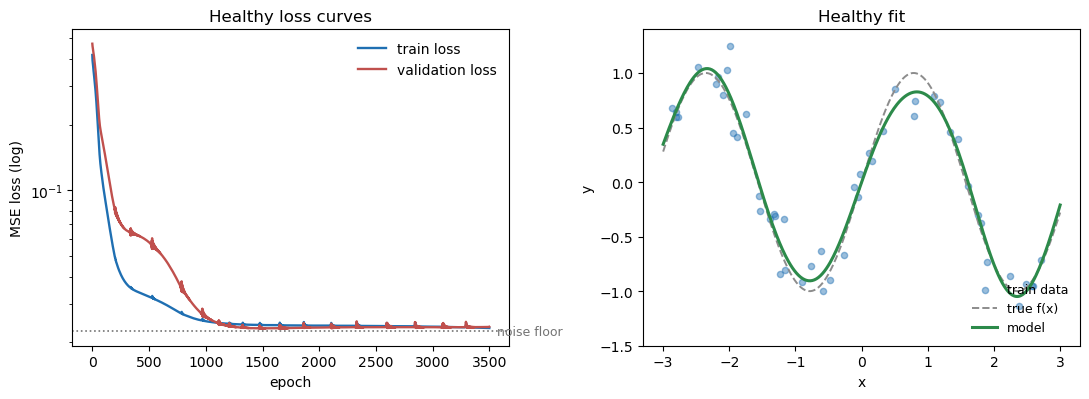

final train 0.0233 | final val 0.0236


In [64]:
model        = make_mlp([1, 32, 1])
optimiser    = torch.optim.Adam(model.parameters(), lr=5e-3)
train_losses, val_losses = train(model, optimiser, n_epochs=3500)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.1))
plot_curves(train_losses, val_losses, "Healthy loss curves", ax=ax[0])
ax[0].text(len(val_losses), NOISE_FLOOR, "  noise floor", color="0.45", fontsize=9, va="center")
plot_fit(model, "Healthy fit", color=C_GOOD, ax=ax[1])
plt.tight_layout()
plt.show()
print(f"final train {train_losses[-1]:.4f} | final val {val_losses[-1]:.4f}")

- Both curves descend and flatten. The gap between them (generlaisation gap) is small and stable.
- Training and validation curves settle right on the noise floor ($\approx 0.0225$).
- The model fit is a smooth curve that captures the trend, and does not pass through every training sample exactly. 

## Part 2 — Underfitting (too little capacity)

When a model is too *simple*, it may be unable to capture represent the true underlying data trend. We say such a model has low capacity and high bias. Let's examine this by creating a very small model with layer dimensions `[1, 2, 1]`.

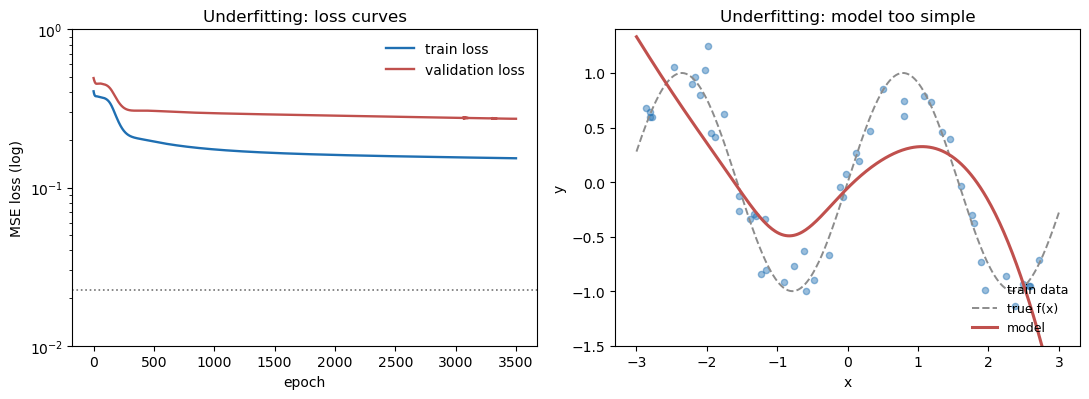

final train 0.1531 | final val 0.2721


In [67]:
model_uf  = make_mlp([1, 2, 1])
optimiser = torch.optim.Adam(model_uf.parameters(), lr=5e-3)
train_losses_uf, val_losses_uf = train(model_uf, optimiser, n_epochs=3500)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.1))
plot_curves(train_losses_uf, val_losses_uf, "Underfitting: loss curves", ax=ax[0])
ax[0].set_ylim(0.01, 1.0)
plot_fit(model_uf, "Underfitting: model too simple", color=C_VAL, ax=ax[1])
plt.tight_layout()
plt.show()
print(f"final train {train_losses_uf[-1]:.4f} | final val {val_losses_uf[-1]:.4f}")

Signs of underfitting are that the training and validation loss curves are both high and flat, far above the noise floor. The model fit is too simple to capture the signal, so it does equally badly on data it has seen and data it hasn't, exhibiting high bias.

Fix: increase model capacity (wider / deeper), train for longer, or increase the learning rate. Swapping in the healthy `[1, 32, 1]` model removes it.

## Part 3 — Overfitting (too much capacity, trained too long)

When a model is too *complex*, the model will begin to try and fit the training data samples exactly, rather than just the underlying trend. It essentially memorises the training data. The issue then is that the model will perform poorly when deployed on data samples it hasn't seen.

Let's construct a large model with layer dimensions `[1, 128, 128, 1]`, trained for a long time.

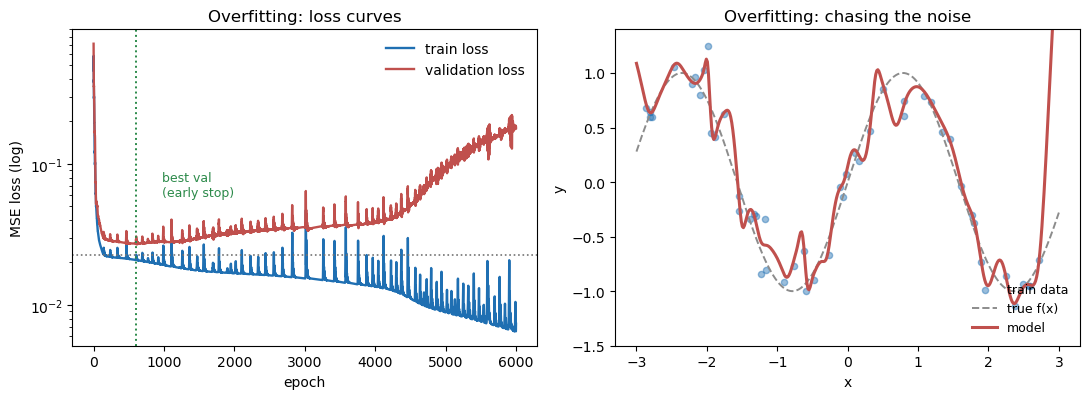

In [69]:
model_of  = make_mlp([1, 128, 128, 1])
optimiser = torch.optim.Adam(model_of.parameters(), lr=5e-3)
train_losses_of, val_losses_of = train(model_of, optimiser, n_epochs=6000)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.1))
plot_curves(train_losses_of, val_losses_of, "Overfitting: loss curves", ax=ax[0], mark_best=True)
plot_fit(model_of, "Overfitting: chasing the noise", color=C_VAL, ax=ax[1])
plt.tight_layout()
plt.show()

Signs of overfitting are that the training loss curve keeps falling below the noise floor while validation bottoms out and then begins to increase.

The model fit shows how the model tries to fit the individual noisy data samples instead of tracking the smooth trend. This is high variance.

The green dotted line marks the best validation epoch. Everything after it is the model getting *worse* at generalising while looking better on train.

### 3.1 Fixing overfitting with weight decay

We keep the same large model and the same data, and add weight decay (`5e-4`). It penalises large weights, so the network lends itself to simpler representations.

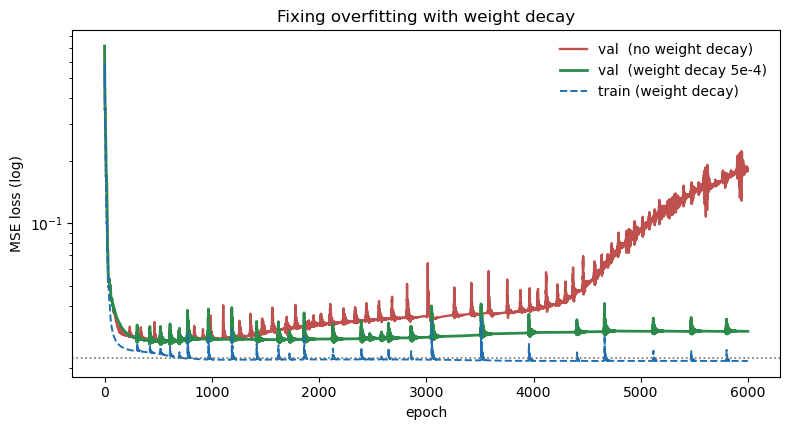

In [72]:
model_wd  = make_mlp([1, 128, 128, 1])
optimiser = torch.optim.Adam(model_wd.parameters(), lr=5e-3, weight_decay=5e-4)
train_losses_wd, val_losses_wd = train(model_wd, optimiser, n_epochs=6000)

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(val_losses_of, color=C_VAL, lw=1.7, label="val  (no weight decay)")
ax.plot(val_losses_wd, color=C_GOOD, lw=2.0, label="val  (weight decay 5e-4)")
ax.plot(train_losses_wd, color=C_TRAIN, lw=1.4, ls="--", label="train (weight decay)")
ax.axhline(NOISE_FLOOR, ls=":", color="0.45", lw=1.2)
ax.set_yscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("MSE loss (log)")
ax.set_title("Fixing overfitting with weight decay")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

The re-increase in the validation loss curve has now disappeared. Instead, with weight-decay, the green loss curve flattens near the floor instead of climbing. 

Other tools for the fixing overfitting include: early stopping, dropout, adding more training data, or reducing the capacity of the model.

## Part 4 — The bias–variance trade-off

Underfitting and overfitting are the two ends of the model capacity axis.

In [73]:
capacities = [("[1,2,1]", [1, 2, 1]), ("[1,8,1]", [1, 8, 1]), ("[1,16,16,1]", [1, 16, 16, 1]), ("[1,48,48,1]", [1, 48, 48, 1])]

final_train_losses, final_val_losses = [], []

for name, model_config in capacities:
    model     = make_mlp(model_config)
    optimiser = torch.optim.Adam(model.parameters(), lr=1e-2)
    train_losses, val_losses = train(model, optimiser, n_epochs=6000)

    final_train_losses.append(train_losses[-1])
    final_val_losses.append(val_losses[-1])

    n_params = sum(p.numel() for p in model.parameters())

    tag = "underfit" if train_losses[-1] > 0.05 else ("overfit" if val_losses[-1] - train_losses[-1] > 0.012 else "just right")
    print(f"{name:16s} params={n_params:6d}  train {train_losses[-1]:.3f}  val {val_losses[-1]:.3f}   <- {tag}")

[1,2,1]          params=     7  train 0.130  val 0.238   <- underfit
[1,8,1]          params=    25  train 0.022  val 0.027   <- just right
[1,16,16,1]      params=   321  train 0.020  val 0.033   <- overfit
[1,48,48,1]      params=  2497  train 0.007  val 0.042   <- overfit


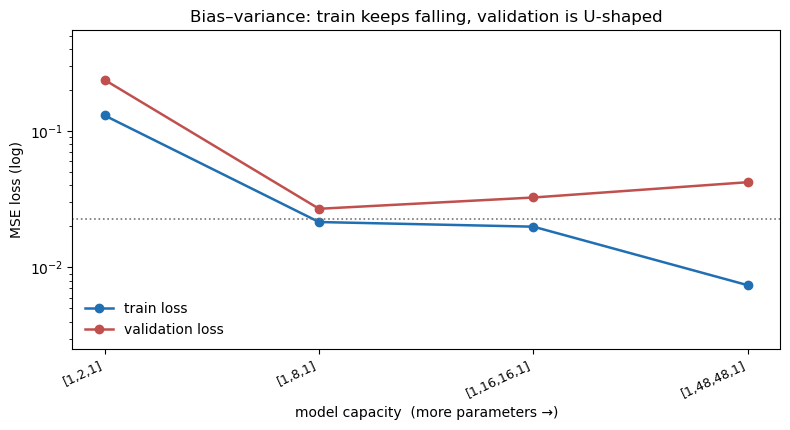

In [75]:
fig, ax = plt.subplots(figsize=(8, 4.4))
xi = np.arange(len(capacities))

ax.plot(xi, final_train_losses, "o-", color=C_TRAIN, lw=1.8, label="train loss")
ax.plot(xi, final_val_losses, "o-", color=C_VAL, lw=1.8, label="validation loss")
ax.axhline(NOISE_FLOOR, ls=":", color="0.45", lw=1.2)
ax.set_yscale("log"); ax.set_xticks(xi)
ax.set_xticklabels([c[0] for c in capacities], rotation=25, ha="right", fontsize=9)
ax.set_xlabel("model capacity  (more parameters \u2192)"); ax.set_ylabel("MSE loss (log)")
ax.set_title("Bias\u2013variance: train keeps falling, validation is U-shaped")
ax.set_ylim(0.0025, 0.55); ax.legend(frameon=False, loc="lower left")
plt.tight_layout()
plt.show()

As we increase model capacity, training loss falls monotonically. At some point, the model capacity becomes large enough that the model begins interpolating the noise rather than extrapolate the underlying trend.

Instead, the validation loss curve first decreases, and then increases as the model begins to memorise the training data, reducing its ability to generalise to new data.

**The practical rule:** pick the smallest model that reaches the validation floor.

## Part 5 — Learning rate

Let's look at a slightly larger model, with layer dimensions `[1, 32, 32, 1]`. We will instead use plain SGD so the effect of learning rate is exposed. Adam adapts it for you and hides the effect.

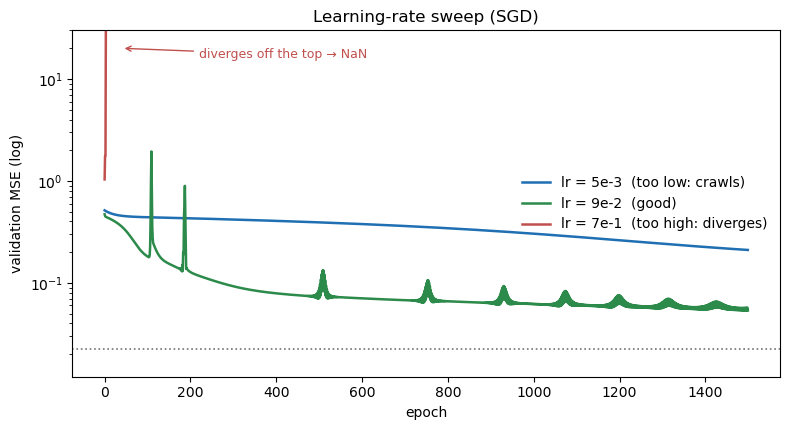

In [76]:
lr_runs = [(5e-3, "lr = 5e-3  (too low: crawls)", C_TRAIN),
           (9e-2, "lr = 9e-2  (good)",            C_GOOD),
           (7e-1, "lr = 7e-1  (too high: diverges)", C_VAL)]

fig, ax = plt.subplots(figsize=(8, 4.4))

for lr, label, colour in lr_runs:
    model     = make_mlp([1, 32, 32, 1])
    optimiser = torch.optim.SGD(model.parameters(), lr=lr)
    train_losses, val_losses = train(model, optimiser, n_epochs=1500)

    ax.plot(np.array(val_losses, dtype=float), color=colour, lw=1.8, label=label)

ax.axhline(NOISE_FLOOR, ls=":", color="0.45", lw=1.2)
ax.set_yscale("log"); ax.set_ylim(0.012, 30)
ax.set_xlabel("epoch"); ax.set_ylabel("validation MSE (log)")
ax.annotate("diverges off the top \u2192 NaN", xy=(40, 20), xytext=(220, 16), color=C_VAL, fontsize=9, arrowprops=dict(arrowstyle="->", color=C_VAL))
ax.set_title("Learning-rate sweep (SGD)"); ax.legend(frameon=False, loc="center right")
plt.tight_layout(); plt.show()

- Too low (blue): the loss slowly falls and never reaches the floor in time.
- Good (green): a steady descent to the noise floor. There is a small early wobble, which would increase if we push the learning rate little higher.
- Too high (red): the loss explodes within a few epochs and becomes `NaN`.

If you're in a setting where your training loss curves diverge, two fixes are either lowering the learning rate, or clipping gradients of the loss functions.

## Part 6 — Batch size and gradient noise

A smaller batch gives a noisier estimate of the gradient. The honest place to see this is the per-update loss — the value you would see logged at each optimiser step. We run mini-batch SGD at the same learning rate for batch sizes 1, 12, and 50 (full batch), and plot the loss of every update.

(On a tiny dataset like ours, the *per-epoch* curve can actually look smoother for small batches, because they take many updates per epoch. The gradient-noise effect is a per-update phenomenon — which is exactly what a real training log shows you.)

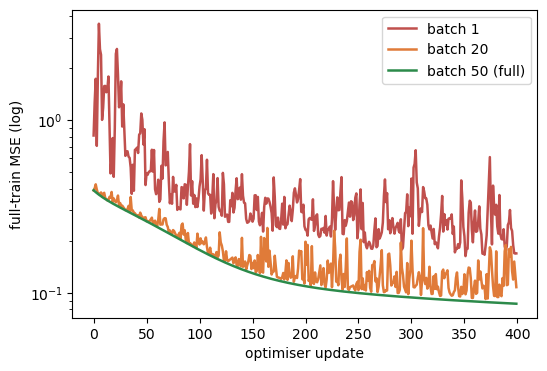

In [79]:
n_samples = x_train.shape[0]
n_updates = 400                      # same #steps for every batch size, not 60 epochs

fig, ax = plt.subplots(figsize=(6, 4))
for batch_size, label, colour in [(1,"batch 1",C_VAL), (20,"batch 20",C_HI), (n_samples,"batch 50 (full)",C_GOOD)]:
    torch.manual_seed(1)

    model   = make_mlp([1, 32, 1])
    opt     = torch.optim.SGD(model.parameters(), lr=0.05)
    loss_fn = nn.MSELoss()
    
    g      = torch.Generator().manual_seed(0)
    loader = DataLoader(TensorDataset(x_train, y_train), 
                                            batch_size=batch_size, 
                                            shuffle=True,
                                            generator=g)
    full = []
    while len(full) < n_updates:
        for x_batch, y_batch in loader:
            opt.zero_grad()
            y_hat = model(x_batch)
            loss  = loss_fn(y_hat, y_batch)
            loss.backward()
            opt.step()

            with torch.no_grad():
                full_loss = loss_fn(model(x_train), y_train).item()
                full.append(full_loss)

            if len(full) >= n_updates:
                break

    ax.plot(full, color=colour, lw=1.8, label=label)

ax.set_yscale("log")
ax.set_xlabel("optimiser update")
ax.set_ylabel("full-train MSE (log)")
ax.legend()
plt.show()

With batch size 1, the loss curve experience lots of noise since each optimiser step follows the gradient of a single point! Instead, full batch gradient descent is much smoother since it averages the gradients over all the data samples.

While small batches give noisier steps, they yield many more parameter updates per epoch. Instead, large batches give smooth, stable steps but fewer updates. 

If you're confronted with a noisy learning curve, two options are to either increase the batch size, or lower the learning rate to match the reduced scale of the parameter update.

## Part 7 — Logging runs with Weights & Biases

Every experiment so far produced a loss curve we looked at once in the notebook and threw away. In reality, you will usually train many variants of an experiment, where you alter hyperparameters, and comparing them to find the set of parameters which yield best performance.

**Weights & Biases** (`wandb`) is the standard tool for this. For each run it records your hyperparameters (the *config*), streams your metrics (the live train / validation curves), and stores artefacts such as plots and model files. Everything is then place in one web dashboard where you can sort, filter, and overlay runs.

### 7.1 Setup

Install once with `pip install wandb`. To stream to the cloud, run `wandb login` in a terminal (or call `wandb.login()`) and paste the API key from your account settings.

You must do the above if you want to use the **online** Weights & Biases cloud service. Otherwise, use **offline** mode: runs are written to a local folder and nothing is uploaded. Change the single flag to `"online"` once you have logged in, and the *same code* streams to the web.

In [80]:
import os, tempfile
import wandb

os.environ["WANDB_SILENT"] = "true"
os.environ["WANDB_DIR"] = tempfile.mkdtemp()   # a dummy directory where offline runs are stored. Use something meaningful in your own code.

WANDB_MODE = "online" # or "offline"
WANDB_PROJECT = "kunming-ws3-diagnostics"
print("wandb", wandb.__version__, "| mode:", WANDB_MODE)

wandb 0.27.0 | mode: online


### 7.2 Wrapping the training loop

We add four W&B calls to the familiar loop:

1. **`wandb.init(project=..., name=..., config=...)`** — start a run and record its hyperparameters. The `config` is what makes runs comparable later.
2. **`wandb.log({...})`** — once per epoch, send the metrics. These become the live charts.
3. **`wandb.log({"fit": wandb.Image(fig)})`** — attach a plot (or any image) as an artefact.
4. **`wandb.summary[...]`** then **`wandb.finish()`** — record final single-value numbers (they populate the runs table) and close the run.

In [81]:
def train_and_log(config, run_name):

    run = wandb.init(project=WANDB_PROJECT,
                     name=run_name,
                     mode=WANDB_MODE,
                     config=config)

    cfg = wandb.config                         # read hyperparameters back from the config

    model   = make_mlp(cfg.sizes)
    opt     = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    loss_fn = nn.MSELoss()

    for epoch in range(cfg.n_epochs):
        # Training
        model.train()
        y_hat = model(x_train)
        loss = loss_fn(y_hat, y_train)
        opt.zero_grad()
        loss.backward()
        opt.step()

        # Evaluate model on validation set
        model.eval()
        with torch.no_grad():
            y_hat_val = model(x_val)
            val_loss = loss_fn(y_hat_val, y_val)
        
        # Stream per-epoch metrics
        wandb.log({"epoch": epoch, "train_loss": loss.item(), "val_loss": val_loss.item()})

    # Generate figures of the final fite and loss curves
    fig, ax = plt.subplots(figsize=(5.5, 4))
    plot_fit(model, f"Fit — {run_name}", color=C_GOOD, ax=ax)
    wandb.log({"fit": wandb.Image(fig)})

    # Attach the final fit as an image artefact
    plt.close(fig)

    # Record single-value summaries
    wandb.summary["final_train"] = loss.item()
    wandb.summary["final_val"] = val_loss


    # Close the run
    wandb.finish()
     
    print(f"logged '{run_name}': final val {val_loss:.4f} (lr={cfg.lr}, wd={cfg.weight_decay})")

    return model

### 7.3 Log a run

We now log a run to `wandb`.

In [83]:
healthy_train_config = {
    "sizes": [1, 32, 1],
    "lr": 3e-3,
    "weight_decay": 5e-4,
    "n_epochs": 3000,
    "optimiser": "adam",
    "noise": NOISE
}

train_and_log(healthy_train_config, run_name="healthy_configuration")

logged 'healthy_configuration': final val 0.0266 (lr=0.003, wd=0.0005)


Sequential(
  (0): Linear(in_features=1, out_features=32, bias=True)
  (1): GELU(approximate='none')
  (2): Linear(in_features=32, out_features=1, bias=True)
)

## Recap

1. Plot train and validation loss together. The generalisation gap between them is where the diagnosis lives.
2. Healthy = both descend and flatten, small stable gap, validation near the noise floor — and the fit *ignores* the noise rather than chasing it.
3. Underfitting vs overfitting are the two ends of the bias–variance trade-off, set by model capacity (among other things).
4. Learning rate: too low crawls, good descends smoothly to the floor, too high diverges to `NaN`.
5. Batch size too small shows up as a jagged per-update loss; the fix is a larger batch or a smaller learning rate.
6. WandB is used for tracking experiments.

### Next: Practical Workshop 3 — *Initialisation and regularisation*
Two of today's fixes — controlling overfitting, and getting signal to flow so a network can train at all — come down to initialisation and regularisation. Next session we cover why bad initial parameters can stop deep networks learning (LeCun, Xavier, Kaiming), and treat normalisation, weight decay, dropout, and early stopping as the standard regularisation toolkit.